In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
from domain import *
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# Visualisation des données pour régions HIMAP

Colonnes disponibles : Index(['FID_bounda', 'OBJECTID_1', 'OBJECTID', 'Primary_ID', 'Secondary_',
       'Third_ID', 'Fourth_ID', 'ZLEVEL', 'Shape_Leng', 'Shape_Le_1',
       'Shape_Area', 'Nr_Region', 'FID_boun_1', 'OBJECTID_2', 'OBJECTID_3',
       'Primary__1', 'Secondary1', 'Third_ID_1', 'Fourth_I_1', 'ZLEVEL_1',
       'Shape_Le_2', 'Shape_Le_3', 'Shape_Ar_1', 'Nr_Regio_1', 'geometry'],
      dtype='object')
   FID_bounda  OBJECTID_1  OBJECTID          Primary_ID Secondary_ Third_ID  \
0           0           1         8  Eastern Hindu Kush      14.01     None   
1           1           3        10    Western Himalaya      14.03     None   
2           2           3        12    Eastern Himalaya      14.03     None   
3           3           3        11    Central Himalaya      14.03     None   
4           4           2         9           Karakoram      14.02     None   

  Fourth_ID  ZLEVEL  Shape_Leng  Shape_Le_1  ...             Primary__1  \
0      None     0.0   27.037593  

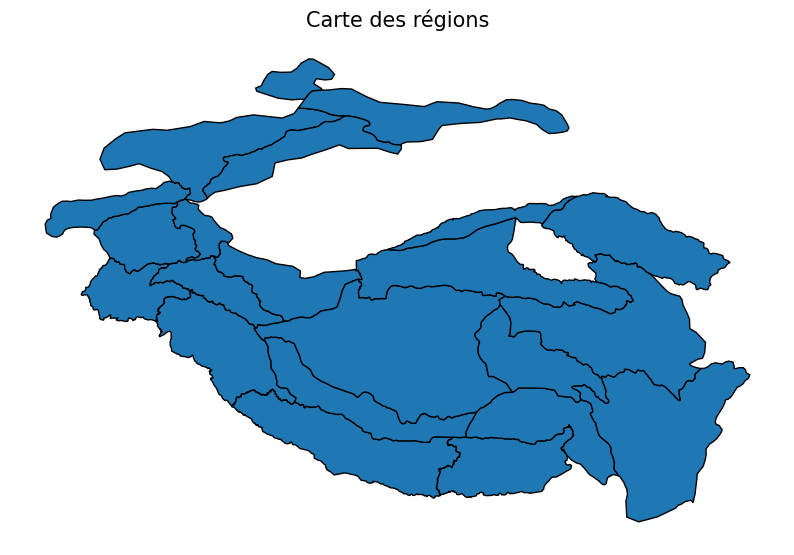

In [2]:
# 1. Chemin vers votre fichier .shp
# (S'assurer que les autres fichiers .dbf, .prj, etc. sont dans le même dossier)
chemin_fichier = "/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"

# 2. Chargement des données
regions = gpd.read_file(chemin_fichier)

# 3. Aperçu des données (pour vérifier le nom des colonnes)
print("Colonnes disponibles :", regions.columns)
print(regions.head())

# 4. Création de la carte
# 'column' permet de colorer selon une donnée (ex: 'Primary_ID')
regions.plot(column=None,
            legend=True, 
            figsize=(10, 10), 
            edgecolor='black') # Dessine les contours

# 5. fignolage de l'affichage
plt.title("Carte des régions", fontsize=15)
plt.axis('off') # Cache les coordonnées X/Y pour un rendu plus propre

# 6. Affichage
plt.show()

# HIMAP grouped regions

In [3]:
# Grouped regions
region_groups = {
        "Tien Shan": [
            "Eastern Tien Shan", "Dzhungarsky Alatau",
            "Northern/Western Tien Shan", "Central Tien Shan"
        ],
        "Pamir Alay": ["Pamir Alay"],
        "Pamir": ["Western Pamir"],
        "Hindu Kush": ["Eastern Hindu Kush"],
        "Karakoram": ["Karakoram"],
        "Kunlun": ["Eastern Pamir", "Western Kunlun Shan"],
        "Spiti Lahaul": ["Western Himalaya"],
        "Central Himalaya": ["Central Himalaya"],
        "Bhutan": ["Eastern Himalaya"],
        "Nyainqentangla": ["Nyainqentanglha"],
        "Inner TP": [
            "Gangdise Mountains", "Tibetan Interior Mountains",
            "Eastern Kunlun Shan", "Altun Shan", "Hengduan Shan",
            "Tanggula Shan", "Eastern Tibetan Mountains", "Qilian Shan"
        ]
    }

# Couleurs pour le plot des régions
group_colors = {
    "Tien Shan": "lightcoral",
    "Pamir Alay": "orange",
    "Pamir": "sandybrown",
    "Hindu Kush": "cadetblue",
    "Karakoram": "darkturquoise",
    "Kunlun": "lightgreen",
    "Spiti Lahaul": "coral",
    "Central Himalaya": "cornflowerblue",
    "Bhutan": "mediumpurple",
    "Nyainqentangla": "mediumvioletred",
    "Inner TP": "mediumaquamarine"
}

In [4]:
# Chargement des données shapefiles
chemin_fichier = "/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"
regions = gpd.read_file(chemin_fichier)

# S'assurer que le shapefile est dans le même système de coordonnées que l'axe
# Si le SHP n'est pas en WGS84 (EPSG:4326), on le convertit
if regions.crs != "EPSG:4326":
    regions = regions.to_crs("EPSG:4326")

# Pour chaque nom dans Primary ID on retourne le nom du groupe auquel il appartient dans region_groups et on met dans la nouvelle colonne 
# "Group"
regions["Group"] = regions["Primary_ID"].apply(
    lambda x: next((g for g, lst in region_groups.items() if x in lst), None)
)

regions_grouped = regions.dropna(subset=["Group"]) # Enlève toutes les lignes où il y a None

# Fusionne toutes les géometries qui ont le même groupe : in fine 11 polygones sans les frontières internes
regions_dissolved = regions_grouped.dissolve(by="Group") 

In [5]:
# gérer le problème des tout petits trous dans les régions regroupés
# juste quelques uns au Tien Shan et Kunlun, et enlève le gros trou dans le Inner TP

def remove_holes(geom):
    
    # Cas polygone simple
    if isinstance(geom, Polygon):
        return Polygon(geom.exterior)

    # Cas multipolygon
    elif isinstance(geom, MultiPolygon):
        return MultiPolygon(
            [Polygon(p.exterior) for p in geom.geoms]
        )

    return geom

regions_dissolved["geometry"] = (regions_dissolved.geometry.apply(remove_holes))

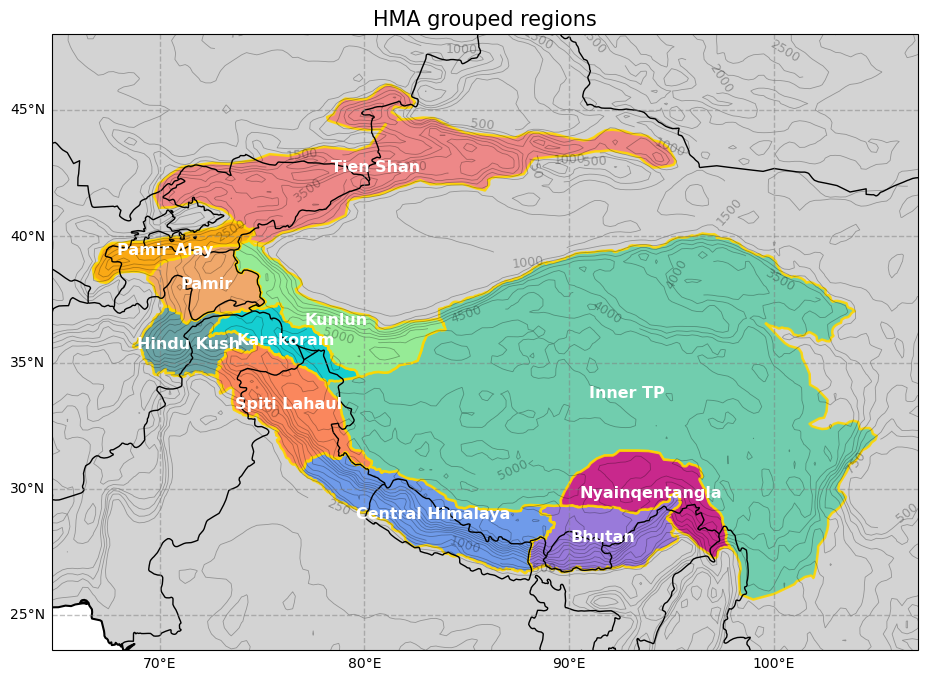

In [6]:
#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

regions_dissolved.plot(
    ax=ax,
    color=regions_dissolved.index.map(group_colors),
    edgecolor="gold",
    linewidth=1.8,
    alpha=0.9
)

# Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND,facecolor="lightgrey")

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

# Labels des régions
for idx, row in regions_dissolved.iterrows():
    centroid = row.geometry.centroid # centroïde de la région
    ax.text(
        centroid.x,
        centroid.y,
        idx,
        fontsize=11.5,
        fontweight='bold',
        ha='center',
        va='center',
        color='white',
        transform=ccrs.PlateCarree(),
        zorder=5
    )

# Extent limits de la figure
bounds = regions_dissolved.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-2, bounds[2]+2, bounds[1]-2, bounds[3]+2],
              crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.title("HMA grouped regions", fontsize=15)
plt.show()

# Saving as shape file .shp

In [7]:
regions_dissolved["Primary_ID"] = regions_dissolved.index # Group et le nouveau Primary_ID

# enlever la colone Group
if "Group" in regions_dissolved.columns:
    regions_dissolved = regions_dissolved.drop(columns=["Group"])

regions_dissolved = regions_dissolved.reset_index(drop=True) # Remettre l'index propre

# Remettre bien la colonne Nr_Regio_1
regions_dissolved["Nr_Regio_1"] = (regions_dissolved.index.to_series().reset_index(drop=True).index + 1)

# Remettre bien la colonne Primary__1
regions_dissolved["Primary__1"] = (
    regions_dissolved['Primary_ID'].astype(str) +
    " (" +
    regions_dissolved["Nr_Regio_1"].astype(str) +
    ")"
)

In [8]:
# Saving file
path = '/bettik/PROJECTS/pr-regional-climate/bricej/HIMAP_grouped_regions'
regions_dissolved.to_file(f"{path}/himap_grouped_regions.shp")

print(f'File Saved : {path}//himap_grouped_regions.shp')

File Saved : /bettik/PROJECTS/pr-regional-climate/bricej/HIMAP_grouped_regions//himap_grouped_regions.shp


# On vérifie les données saved

In [9]:
dg = gpd.read_file(f'{path}/himap_grouped_regions.shp')
dg.head()

,FID_bounda,OBJECTID_1,OBJECTID,Primary_ID,Secondary_,Third_ID,Fourth_ID,ZLEVEL,Shape_Leng,Shape_Le_1,...,Primary__1,Secondary1,Third_ID_1,Fourth_I_1,ZLEVEL_1,Shape_Le_2,Shape_Le_3,Shape_Ar_1,Nr_Regio_1,geometry
0,2,3,12,Bhutan,14.03,None,None,0.0,35.436097,35.436097,...,Bhutan (1),14.03,None,None,0.0,35.436097,35.436097,21.948479,1,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
1,3,3,11,Central Himalaya,14.03,None,None,0.0,35.436097,35.436097,...,Central Himalaya (2),14.03,None,None,0.0,35.436097,35.436097,21.948479,2,"POLYGON ((80.9356 30.70763, 80.98096 30.6962, ..."
2,0,1,8,Hindu Kush,14.01,None,None,0.0,27.037593,19.743414,...,Hindu Kush (3),14.01,None,None,0.0,27.037593,19.743414,9.504227,3,"POLYGON ((73.45169 36.98397, 73.44597 36.96573..."
3,11,0,17,Inner TP,13.07,None,None,0.0,0.000000,0.000000,...,Inner TP (4),13.07,None,None,0.0,0.000000,0.000000,0.000000,4,"POLYGON ((103.35322 29.42119, 103.21165 29.272..."
4,4,2,9,Karakoram,14.02,None,None,0.0,23.361411,23.361411,...,Karakoram (5),14.02,None,None,0.0,23.361411,23.361411,10.362994,5,"POLYGON ((75.87363 37.3118, 75.89061 37.31113,..."


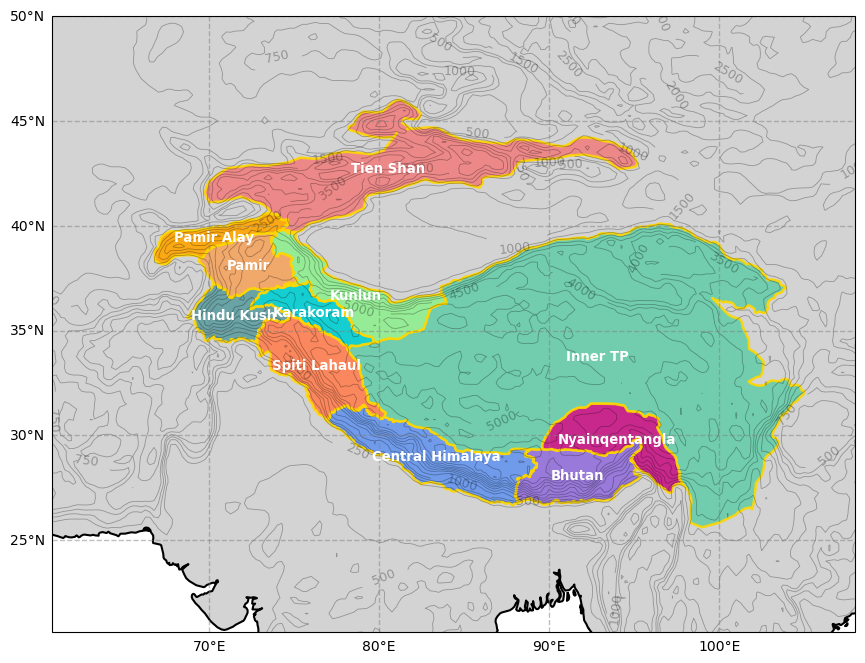

In [10]:
#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

dg.plot(
    ax=ax,
    color = dg["Primary_ID"].map(group_colors),
    edgecolor="gold",
    linewidth=1.8,
    alpha=0.9
)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND,facecolor="lightgrey")

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

# Labels des régions
for idx, row in dg.iterrows():
    centroid = row.geometry.centroid # centroïde de la région
    ax.text(
        centroid.x,
        centroid.y,
        row["Primary_ID"],
        fontsize=9.5,
        fontweight='bold',
        ha='center',
        va='center',
        color='white',
        transform=ccrs.PlateCarree(),
        zorder=5
    )

# Extent limits de la figure
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-6, bounds[2]+3, bounds[1]-5, bounds[3]+4],
              crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

#plt.title("HMA grouped regions", fontsize=15)
plt.show()

## Combined with five big regions

In [11]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

#CH
dsCH=field_dom(elev,'CH')
dsSH_CH=dsCH
LONS_CH,LATS_CH=dsCH.longitude,dsCH.latitude

#HK
dsHK=field_dom(elev,'HK')
dsSH_HK=dsHK
LONS_HK,LATS_HK=dsHK.longitude,dsHK.latitude

#TP
dsTP=field_dom(elev,'TP')
dsSH_TP=dsTP
LONS_TP,LATS_TP=dsTP.longitude,dsTP.latitude

#SEH
dsSEH=field_dom(elev,'SEH')
dsSH_SEH=dsSEH
LONS_SEH,LATS_SEH=dsSEH.longitude,dsSEH.latitude

#SL
dsSL=field_dom(elev,'SL')
dsSH_SL=dsSL
LONS_SL,LATS_SL=dsSL.longitude,dsSL.latitude

In [12]:
# Compute rectangle coordinates automatically
CH_box = [LONS_CH.min().item(), LONS_CH.max().item(),
             LATS_CH.min().item(), LATS_CH.max().item()]

HK_box = [LONS_HK.min().item(), LONS_HK.max().item(),
             LATS_HK.min().item(), LATS_HK.max().item()]

TP_box = [LONS_TP.min().item(), LONS_TP.max().item(),
             LATS_TP.min().item(), LATS_TP.max().item()]

SEH_box = [LONS_SEH.min().item(), LONS_SEH.max().item(),
             LATS_SEH.min().item(), LATS_SEH.max().item()]

SL_box = [LONS_SL.min().item(), LONS_SL.max().item(),
             LATS_SL.min().item(), LATS_SL.max().item()]

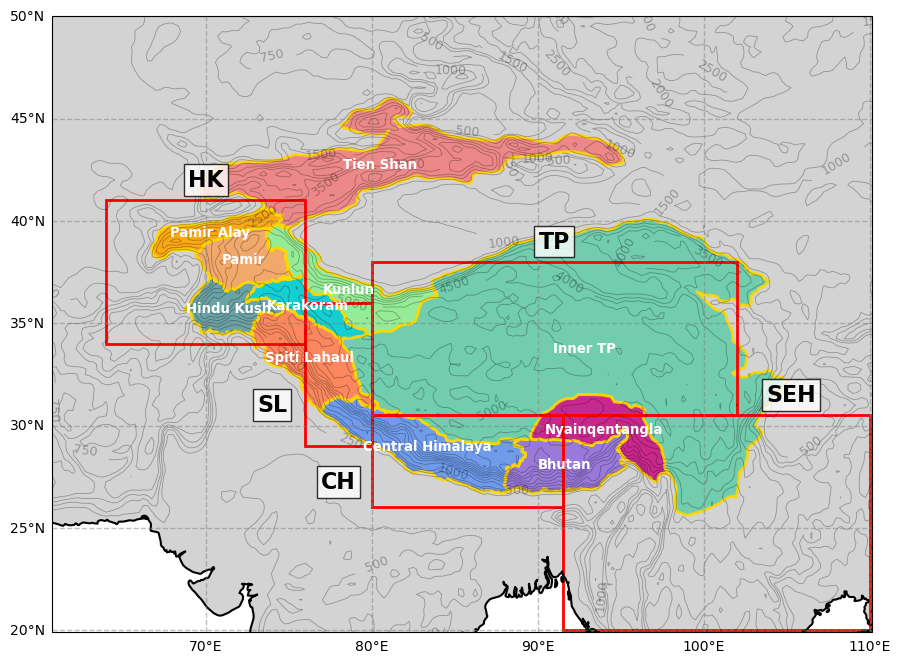

In [13]:
#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

dg.plot(
    ax=ax,
    color = dg["Primary_ID"].map(group_colors),
    edgecolor="gold",
    linewidth=2,
    alpha=0.9
)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND,facecolor="lightgrey")

#Courbes de niveau
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

# Labels des régions
for idx, row in dg.iterrows():
    centroid = row.geometry.centroid # centroïde de la région
    ax.text(
        centroid.x,
        centroid.y,
        row["Primary_ID"],
        fontsize=9.5,
        fontweight='bold',
        ha='center',
        va='center',
        color='white',
        transform=ccrs.PlateCarree(),
        zorder=5
    )

# Add red rectangles for subdomains
for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree())
    ax.add_patch(rect)

#Add text zone
latS, latN, lonW, lonE = coord_domain('HK')
ax.text((lonW + lonE) / 2, latN + 1, "HK",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('TP')
ax.text((lonW + lonE) / 2, latN + 1, "TP",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('CH')
ax.text(lonW - 2,(latS + latN) / 2 - 1, "CH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SEH')
ax.text((lonW + lonE) / 2 + 4.5, latN + 1, "SEH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SL')
ax.text(lonW - 2,(latS + latN) / 2 - 1.5, "SL",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# Extent limits de la figure
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-6, bounds[2]+5.1, bounds[1]-5.7, bounds[3]+4],
              crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

#plt.title("HMA grouped regions", fontsize=15)
plt.show()

# Figure final for repport

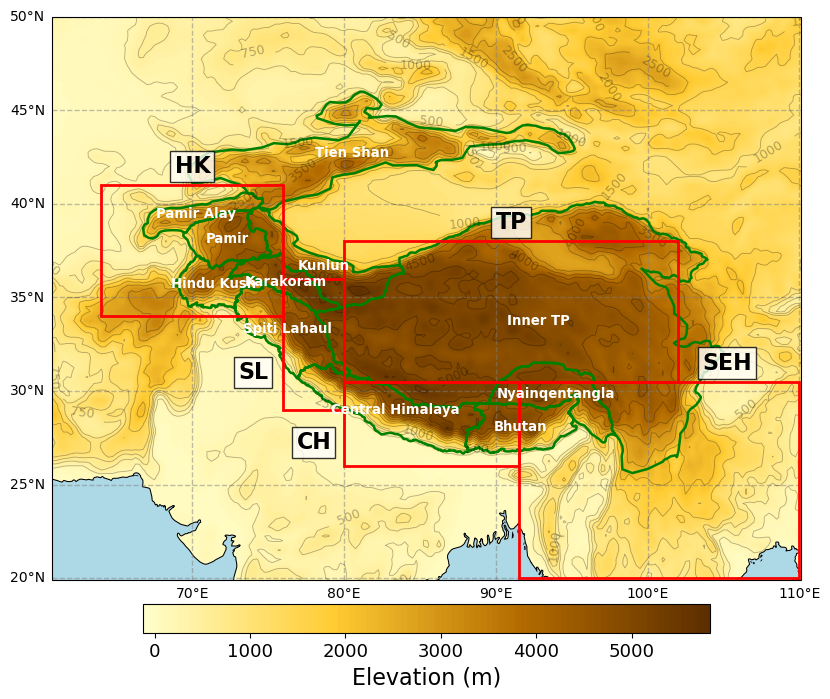

In [14]:
# colors for elevation on land
cmap = mcolors.LinearSegmentedColormap.from_list(
    "yellow_brown",
    ["#ffffcc",  # jaune très clair
     "#ffcc33",  # jaune doré
     "#b36b00",  # brun orangé
     "#5c2e00"]  # brun foncé
)

#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

dg.plot(
    ax=ax,
    facecolor="none",
    edgecolor="green",
    linewidth=1.8, zorder = 5
)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=2)
ax.add_feature(cfeature.LAND,facecolor="none", zorder=2)

cf = ax.contourf(
    elev.longitude,
    elev.latitude,
    elev,
    levels=100,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    zorder=1
)

#Courbes de niveau
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree(), zorder=3)
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

# Labels des régions
for idx, row in dg.iterrows():
    centroid = row.geometry.centroid # centroïde de la région
    ax.text(
        centroid.x,
        centroid.y,
        row["Primary_ID"],
        fontsize=9.5,
        fontweight='bold',
        ha='center',
        va='center',
        color='white',
        transform=ccrs.PlateCarree(),
        zorder=8
    )
#color bar
cbar = fig.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Elevation (m)", fontsize=16)
cbar.set_ticks(list(range(0, 6000, 1000)))
cbar.ax.tick_params(labelsize=13)

# Add red rectangles for subdomains
for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), zorder=6)
    ax.add_patch(rect)

#Add text zone
latS, latN, lonW, lonE = coord_domain('HK')
ax.text((lonW + lonE) / 2, latN + 1, "HK",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('TP')
ax.text((lonW + lonE) / 2, latN + 1, "TP",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('CH')
ax.text(lonW - 2,(latS + latN) / 2 - 1, "CH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SEH')
ax.text((lonW + lonE) / 2 + 4.5, latN + 1, "SEH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SL')
ax.text(lonW - 2,(latS + latN) / 2 - 1.5, "SL",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# Extent limits de la figure
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-6, bounds[2]+5.1, bounds[1]-5.7, bounds[3]+4],
              crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

#plt.title("HMA grouped regions", fontsize=15)
plt.show()

# With glacierzied area RGIv7.0

In [27]:
# Central Asia glaciers
glacier13 = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/RGI2000-v7.0-G-13_central_asia/RGI2000-v7.0-G-13_central_asia.shp')

# South West Asia glaciers
glacier14 = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/RGI2000-v7.0-G-14_south_asia_west/RGI2000-v7.0-G-14_south_asia_west.shp')

# South East Asia glaciers
glacier15 = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/RGI2000-v7.0-G-15_south_asia_east/RGI2000-v7.0-G-15_south_asia_east.shp')


In [40]:
# rivers
#rivers = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/rivers/ne_10m_rivers_lake_centerlines.shp')

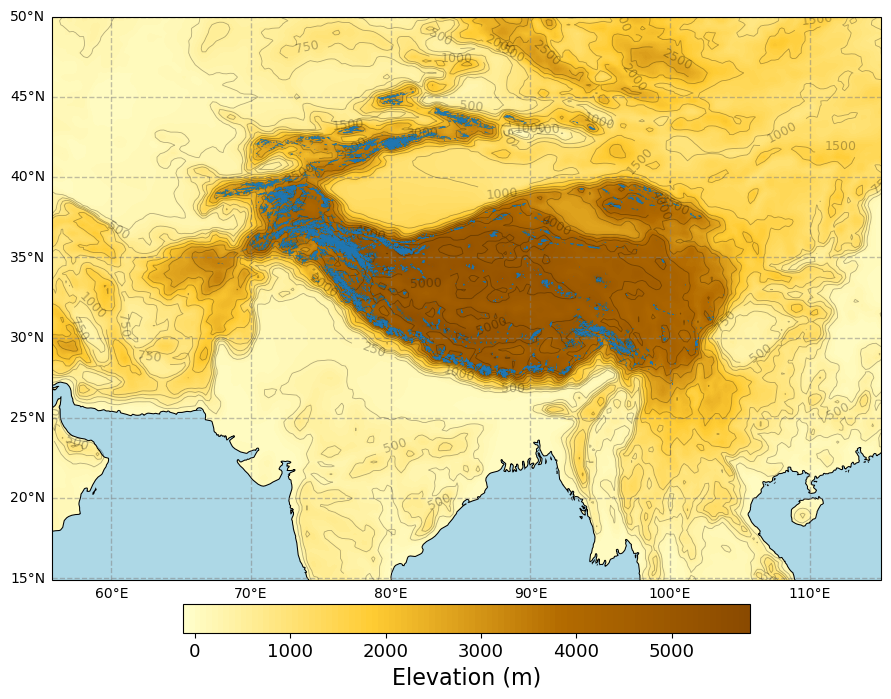

In [44]:
# colors for elevation on land
cmap = mcolors.LinearSegmentedColormap.from_list(
    "yellow_brown",
    ["#ffffcc",  # jaune très clair
     "#ffcc33",  # jaune doré
     "#b36b00",  # brun orangé
     "#8a4a00"]  # brun relativement clair
)

#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# glacierized area
glacier13.plot(
    ax=ax,
    color = "tab:blue",
    edgecolor="tab:blue",
    linewidth=0.2,
    alpha=0.9,
    zorder=20
)
glacier14.plot(
    ax=ax,
    color = "tab:blue",
    edgecolor="tab:blue",
    linewidth=0.2,
    alpha=0.9,
    zorder=20
)
glacier15.plot(
    ax=ax,
    color = "tab:blue",
    edgecolor="tab:blue",
    linewidth=0.2,
    alpha=0.9,
    zorder=20
)

# rivers
#rivers.plot(
#    ax=ax,
#    color = "skyblue",
#    linewidth=0.5,
#    alpha=0.9,
#    zorder=20
#)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=2)
ax.add_feature(cfeature.LAND,facecolor="none", zorder=2)

cf = ax.contourf(
    elev.longitude,
    elev.latitude,
    elev,
    levels=100,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    zorder=1
)

#Courbes de niveau
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree(), zorder=3)
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#color bar
cbar = fig.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Elevation (m)", fontsize=16)
cbar.set_ticks(list(range(0, 6000, 1000)))
cbar.ax.tick_params(labelsize=13)


# Extent limits de la figure
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-11, bounds[2]+10.1, bounds[1]-10.7, bounds[3]+4],
              crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

#plt.title("HMA grouped regions", fontsize=15)
plt.show()

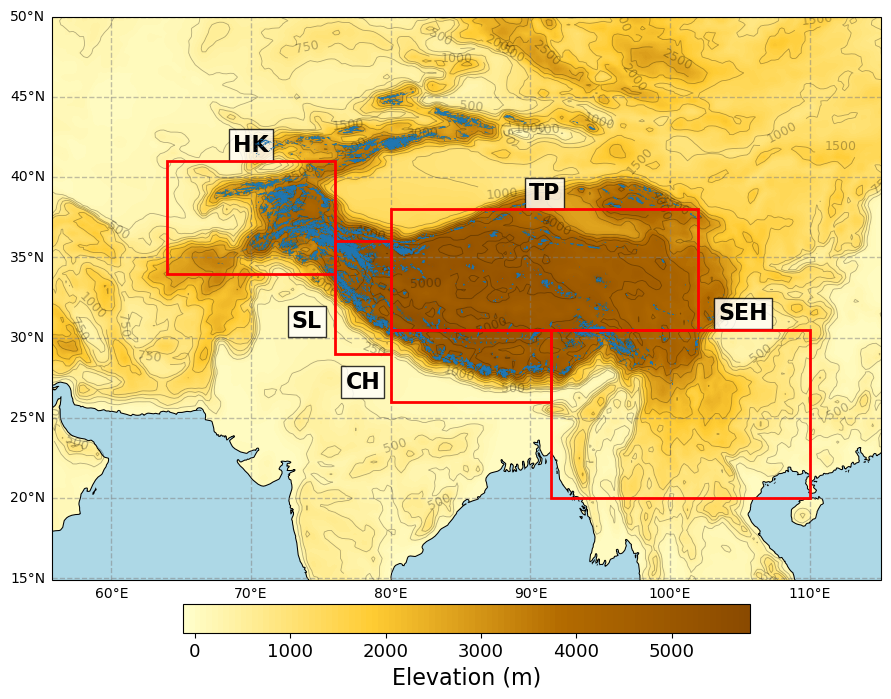

In [45]:
# colors for elevation on land
cmap = mcolors.LinearSegmentedColormap.from_list(
    "yellow_brown",
    ["#ffffcc",  # jaune très clair
     "#ffcc33",  # jaune doré
     "#b36b00",  # brun orangé
     "#8a4a00"]  # brun relativement clair
)

#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# glacierized area
glacier13.plot(
    ax=ax,
    color = "tab:blue",
    edgecolor="tab:blue",
    linewidth=0.2,
    alpha=0.9,
    zorder=20
)
glacier14.plot(
    ax=ax,
    color = "tab:blue",
    edgecolor="tab:blue",
    linewidth=0.2,
    alpha=0.9,
    zorder=20
)
glacier15.plot(
    ax=ax,
    color = "tab:blue",
    edgecolor="tab:blue",
    linewidth=0.2,
    alpha=0.9,
    zorder=20
)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=2)
ax.add_feature(cfeature.LAND,facecolor="none", zorder=2)

cf = ax.contourf(
    elev.longitude,
    elev.latitude,
    elev,
    levels=100,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    zorder=1
)

#Courbes de niveau
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree(), zorder=3)
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#color bar
cbar = fig.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Elevation (m)", fontsize=16)
cbar.set_ticks(list(range(0, 6000, 1000)))
cbar.ax.tick_params(labelsize=13)

# Add red rectangles for subdomains
for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), zorder=21)
    ax.add_patch(rect)

#Add text zone
latS, latN, lonW, lonE = coord_domain('HK')
ax.text((lonW + lonE) / 2, latN + 1, "HK",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('TP')
ax.text((lonW + lonE) / 2, latN + 1, "TP",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('CH')
ax.text(lonW - 2,(latS + latN) / 2 - 1, "CH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SEH')
ax.text((lonW + lonE) / 2 + 4.5, latN + 1, "SEH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SL')
ax.text(lonW - 2,(latS + latN) / 2 - 1.5, "SL",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))


# Extent limits de la figure
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-11, bounds[2]+10.1, bounds[1]-10.7, bounds[3]+4],
              crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

#plt.title("HMA grouped regions", fontsize=15)
plt.show()